# Community detection
## Example 1: AL city metworks
Data from news desert project ([paper linked here](https://asistdl.onlinelibrary.wiley.com/doi/abs/10.1002/pra2.1516))

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

node_table = pd.read_csv("./data/Alabama_city_network/node_table.csv")
edge_table = pd.read_csv("./data/Alabama_city_network/edge_table.csv")

graph = nx.from_pandas_edgelist(edge_table, source="Source", target="Target", edge_attr="Weight")

size_dict = dict(zip(node_table["Id"], node_table["Size"]))
nx.set_node_attributes(graph, size_dict, "size")

In [6]:
# inspect the network

print("Number of nodes:", graph.number_of_nodes())
print("Number of edges:", graph.number_of_edges())
print("\nNode examples:", list(graph.nodes())[:10])
print("\nEdges examples", list(graph.edges())[:10])

Number of nodes: 232
Number of edges: 4448

Node examples: ['Northport', 'Tuscaloosa', 'Birmingham', 'Montgomery', 'Auburn', 'Demopolis', 'Fayette', 'Mobile', 'Brookwood', 'Carrollton']

Edges examples [('Northport', 'Tuscaloosa'), ('Northport', 'Fayette'), ('Northport', 'Carrollton'), ('Northport', 'Demopolis'), ('Northport', 'Birmingham'), ('Northport', 'Livingston'), ('Northport', 'Brookwood'), ('Northport', 'Eutaw'), ('Northport', 'Montgomery'), ('Northport', 'Moundville')]


In [ ]:
# inspect network metrics

print("Density (how connected a network is: D = Number of actual edges / Number of possible edges):", nx.density(graph))
print("Average degree:", sum(dict(graph.degree()).values()) / graph.number_of_nodes())
print("Local cluster coefficient of node Tuscaloosa", nx.clustering(graph, nodes='Tuscaloosa', weight=None))
print("Average local cluster coefficient:", nx.average_clustering(graph))
print("Global cluster coefficient:", nx.transitivity(graph))

### Louvain method

In [ ]:
communities = nx.community.louvain_communities(graph, seed=123)
print("Modularity score", nx.community.modularity(graph, communities))

In [17]:

node_to_comm = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = i

colors = []
for node in graph.nodes():
    colors.append(node_to_comm[node])


In [56]:
len(communities)

6

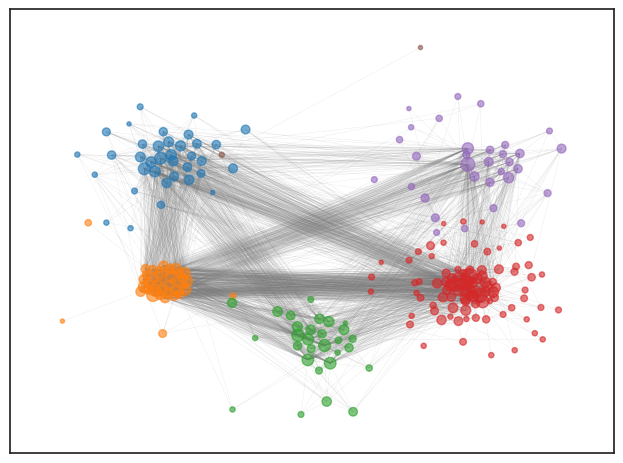

In [63]:
# Compute positions for the node clusters as if they were themselves nodes in a
# supergraph using a larger scale factor

sns.set_theme(style="white")
supergraph = nx.cycle_graph(len(communities))
superpos = nx.spring_layout(supergraph, scale=1.8, seed=429)

# Use the "supernode" positions as the center of each node cluster
centers = list(superpos.values())
pos = {}
for center, comm in zip(centers, communities):
    pos.update(nx.spring_layout(nx.subgraph(graph, comm), center=center, seed=1430))

# Nodes colored by cluster
for nodes, clr in zip(communities, ("tab:blue", "tab:orange", "tab:green", "tab:red","tab:purple","tab:brown")):
    node_sizes = [13*np.log1p(size_dict[node]) for node in nodes]
    nx.draw_networkx_nodes(graph, pos=pos, nodelist=nodes, node_color=clr, node_size=node_sizes, alpha=0.6)
nx.draw_networkx_edges(graph, pos=pos, edge_color="gray", width=0.08, alpha=0.6)

plt.tight_layout()
plt.show()

### Girvan-Newman method
Not really great for this network, since there is not obvious bridge node

In [4]:
# community detection using Girvan-Newman method

communities = list(nx.community.girvan_neswman(graph))

# Modularity -> measures the strength of division of a network into modules
modularity_df = pd.DataFrame(
    [
        [k + 1, nx.community.modularity(graph, communities[k])]
        for k in range(len(communities))
    ],
    columns=["k", "modularity"],
)


In [7]:
modularity_df.nlargest(n=5, columns="modularity")

,k,modularity
184,185,0.051446
185,186,0.051122
186,187,0.051051
187,188,0.049554
188,189,0.048589


In [29]:

tmp_ = modularity_df.copy()
tmp_['singletons'] = tmp_['k'].apply(lambda x: sum([len(i)==1 for i in communities[x-1]]))
tmp_['average_community_size'] = tmp_['k'].apply(lambda x: np.mean([len(i) for i in communities[x-1]]))


<Axes: xlabel='k', ylabel='modularity'>

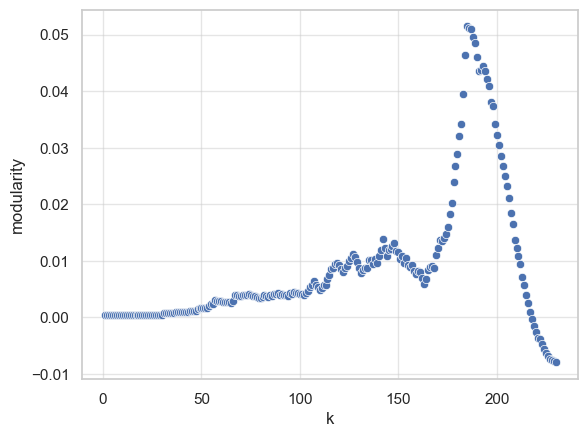

In [39]:
sns.set_theme(style="whitegrid")
sns.scatterplot(data=tmp_, x='k', y='modularity')

In [42]:
[len(i) for i in communities[60]]

[168,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1]

## Example 2

In [64]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

edge_list = [(1,2), (1,3), (1,4), (2,3), (3,4), (4,5),
             (5,6), (5,7), (6,9), (6,8), (8,9)]

graph_2 = nx.Graph()
graph_2.add_edges_from(edge_list)

In [66]:
print("Number of nodes:", graph_2.number_of_nodes())
print("Number of edges:", graph_2.number_of_edges())
print("Density:", nx.density(graph_2))
print("Average degree:", sum(dict(graph_2.degree()).values()) / graph_2.number_of_nodes())
print("Local cluster coefficient of node 1", nx.clustering(graph_2, nodes=1, weight=None))
print("Average local cluster coefficient:", nx.average_clustering(graph_2))
print("Global cluster coefficient:", nx.transitivity(graph_2))

Number of nodes: 9
Number of edges: 11
Density: 0.3055555555555556
Average degree: 2.4444444444444446
Local cluster coefficient of node 1 0.6666666666666666
Average local cluster coefficient: 0.5555555555555556
Global cluster coefficient: 0.5


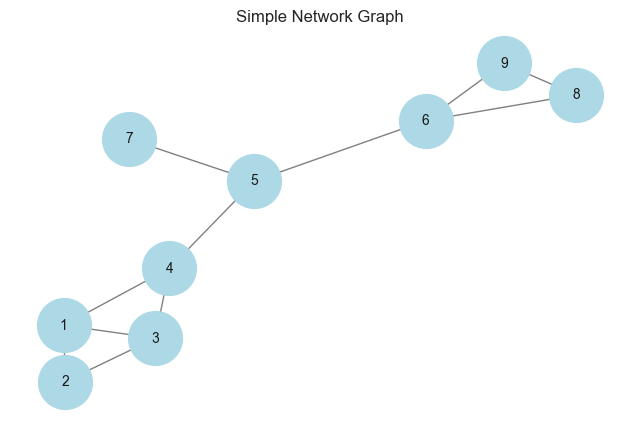

In [67]:

sns.set_theme(style="white", font_scale=1)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

pos = nx.spring_layout(graph_2, seed=1)

nx.draw(
    graph_2,
    pos,
    with_labels=True,
    node_size=1500,
    node_color="lightblue",
    font_size=10,
    edge_color="gray", ax=ax
)

plt.title("Simple Network Graph")
plt.show()

In [68]:
# community detection using Girvan-Newman method

communities_2 = list(nx.community.girvan_newman(graph_2))

# Modularity -> measures the strength of division of a network into modules
modularity_df_2 = pd.DataFrame(
    [
        [k + 1, nx.community.modularity(graph_2, communities_2[k])]
        for k in range(len(communities_2))
    ],
    columns=["k", "modularity"],
)

# compute the numbers of singleton communities and average community size
modularity_df_2['singletons'] = modularity_df_2['k'].apply(lambda x: sum([len(i)==1 for i in communities_2[x-1]]))
modularity_df_2['average_community_size'] = modularity_df_2['k'].apply(lambda x: np.mean([len(i) for i in communities_2[x-1]]))

In [69]:
[print(community) for community in communities_2]

({1, 2, 3, 4}, {5, 6, 7, 8, 9})
({1, 2, 3, 4}, {5, 7}, {8, 9, 6})
({1, 3, 4}, {2}, {5, 7}, {8, 9, 6})
({1}, {2}, {3, 4}, {5, 7}, {8, 9, 6})
({1}, {2}, {3}, {4}, {5, 7}, {8, 9, 6})
({1}, {2}, {3}, {4}, {5}, {8, 9, 6}, {7})
({1}, {2}, {3}, {4}, {5}, {6}, {7}, {8, 9})
({1}, {2}, {3}, {4}, {5}, {6}, {7}, {9}, {8})


[None, None, None, None, None, None, None, None]

In [72]:
chosen_communities = communities_2[1]
node_to_comm = {}
for i, comm in enumerate(chosen_communities):
    for node in comm:
        node_to_comm[node] = i

colors = []
for node in graph_2.nodes():
    colors.append(node_to_comm[node])


Text(0.5, 1.0, 'Communities (Girvan–Newman)')

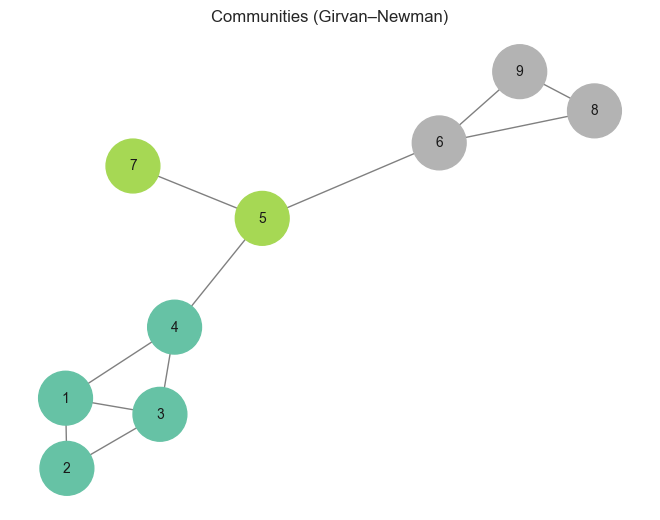

In [73]:

pos = nx.spring_layout(graph_2, seed=1)

nx.draw(
    graph_2,
    pos,
    node_color=colors,
    cmap=plt.cm.Set2,   # nice categorical colors
    with_labels=True,
    node_size=1500,
    font_size=10,
    edge_color="gray"
)

plt.title("Communities (Girvan–Newman)")


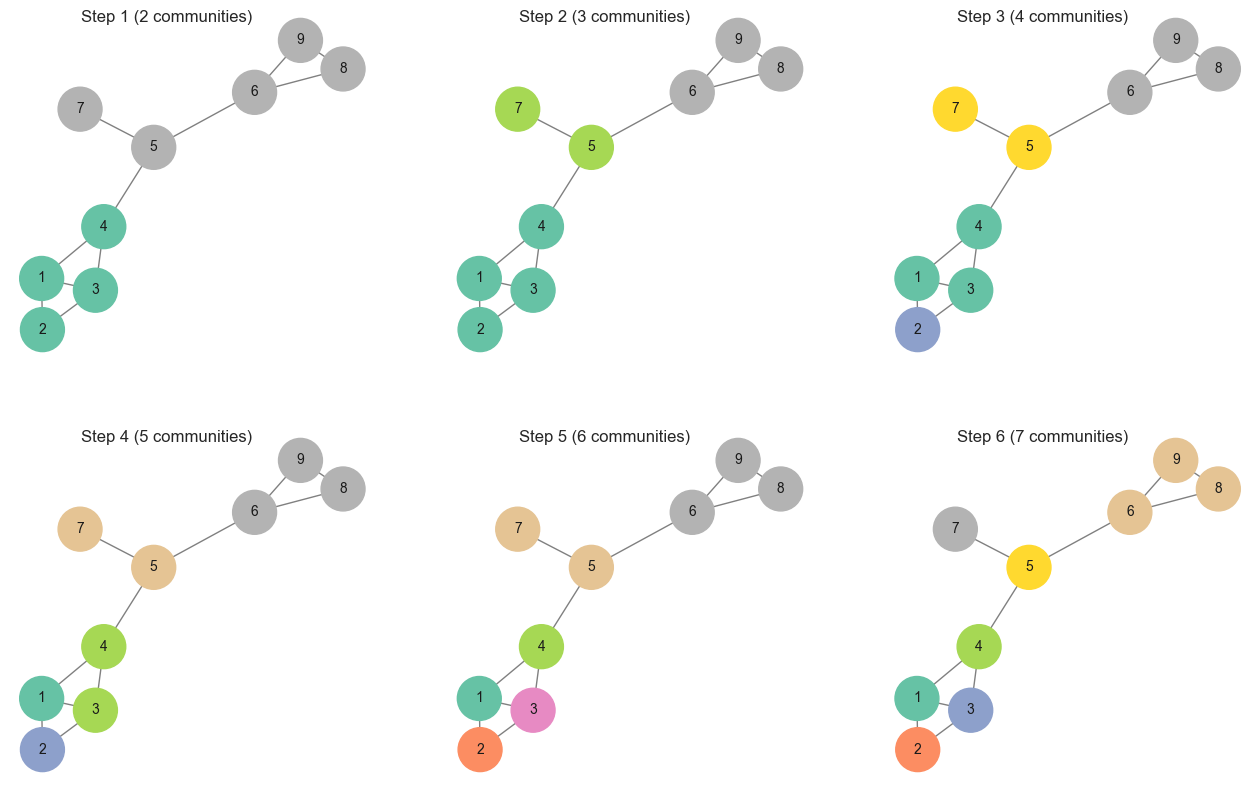

In [90]:
# Plotting the steps of Girvan-Newman method community detection process

sns.set_theme(style="white")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

i_ = 1
for chosen_communities, ax in zip(communities_2[:6], axes.flat):
    node_to_comm = {}
    for i, comm in enumerate(chosen_communities):
        for node in comm:
            node_to_comm[node] = i

    colors = []
    for node in graph_2.nodes():
        colors.append(node_to_comm[node])

    pos = nx.spring_layout(graph_2, seed=1)

    nx.draw(
        graph_2,
        pos,
        node_color=colors,
        cmap=plt.cm.Set2,   # nice categorical colors
        with_labels=True,
        node_size=1000,
        font_size=10,
        edge_color="gray", ax=ax
    )

    ax.annotate(f"Step {i_} ({len(chosen_communities)} communities)", xy=(-0.3, 1))
    i_ += 1

